In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [10]:
# Load the dataset
df = pd.read_csv('Crop_recommendation.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())

Dataset Shape: (2200, 8)

First few rows:
    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), st

In [11]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())
print("\n% of Missing Values:")
print((df.isnull().sum() / len(df)) * 100)

# Data types
print("\nData Types:")
print(df.dtypes)

# Check unique values for categorical columns
print("\nUnique Values per Column:")
print(df.nunique())

Missing Values:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

% of Missing Values:
N              0.0
P              0.0
K              0.0
temperature    0.0
humidity       0.0
ph             0.0
rainfall       0.0
label          0.0
dtype: float64

Data Types:
N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label              str
dtype: object

Unique Values per Column:
N               137
P               117
K                73
temperature    2200
humidity       2200
ph             2200
rainfall       2200
label            22
dtype: int64


Numerical Columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']


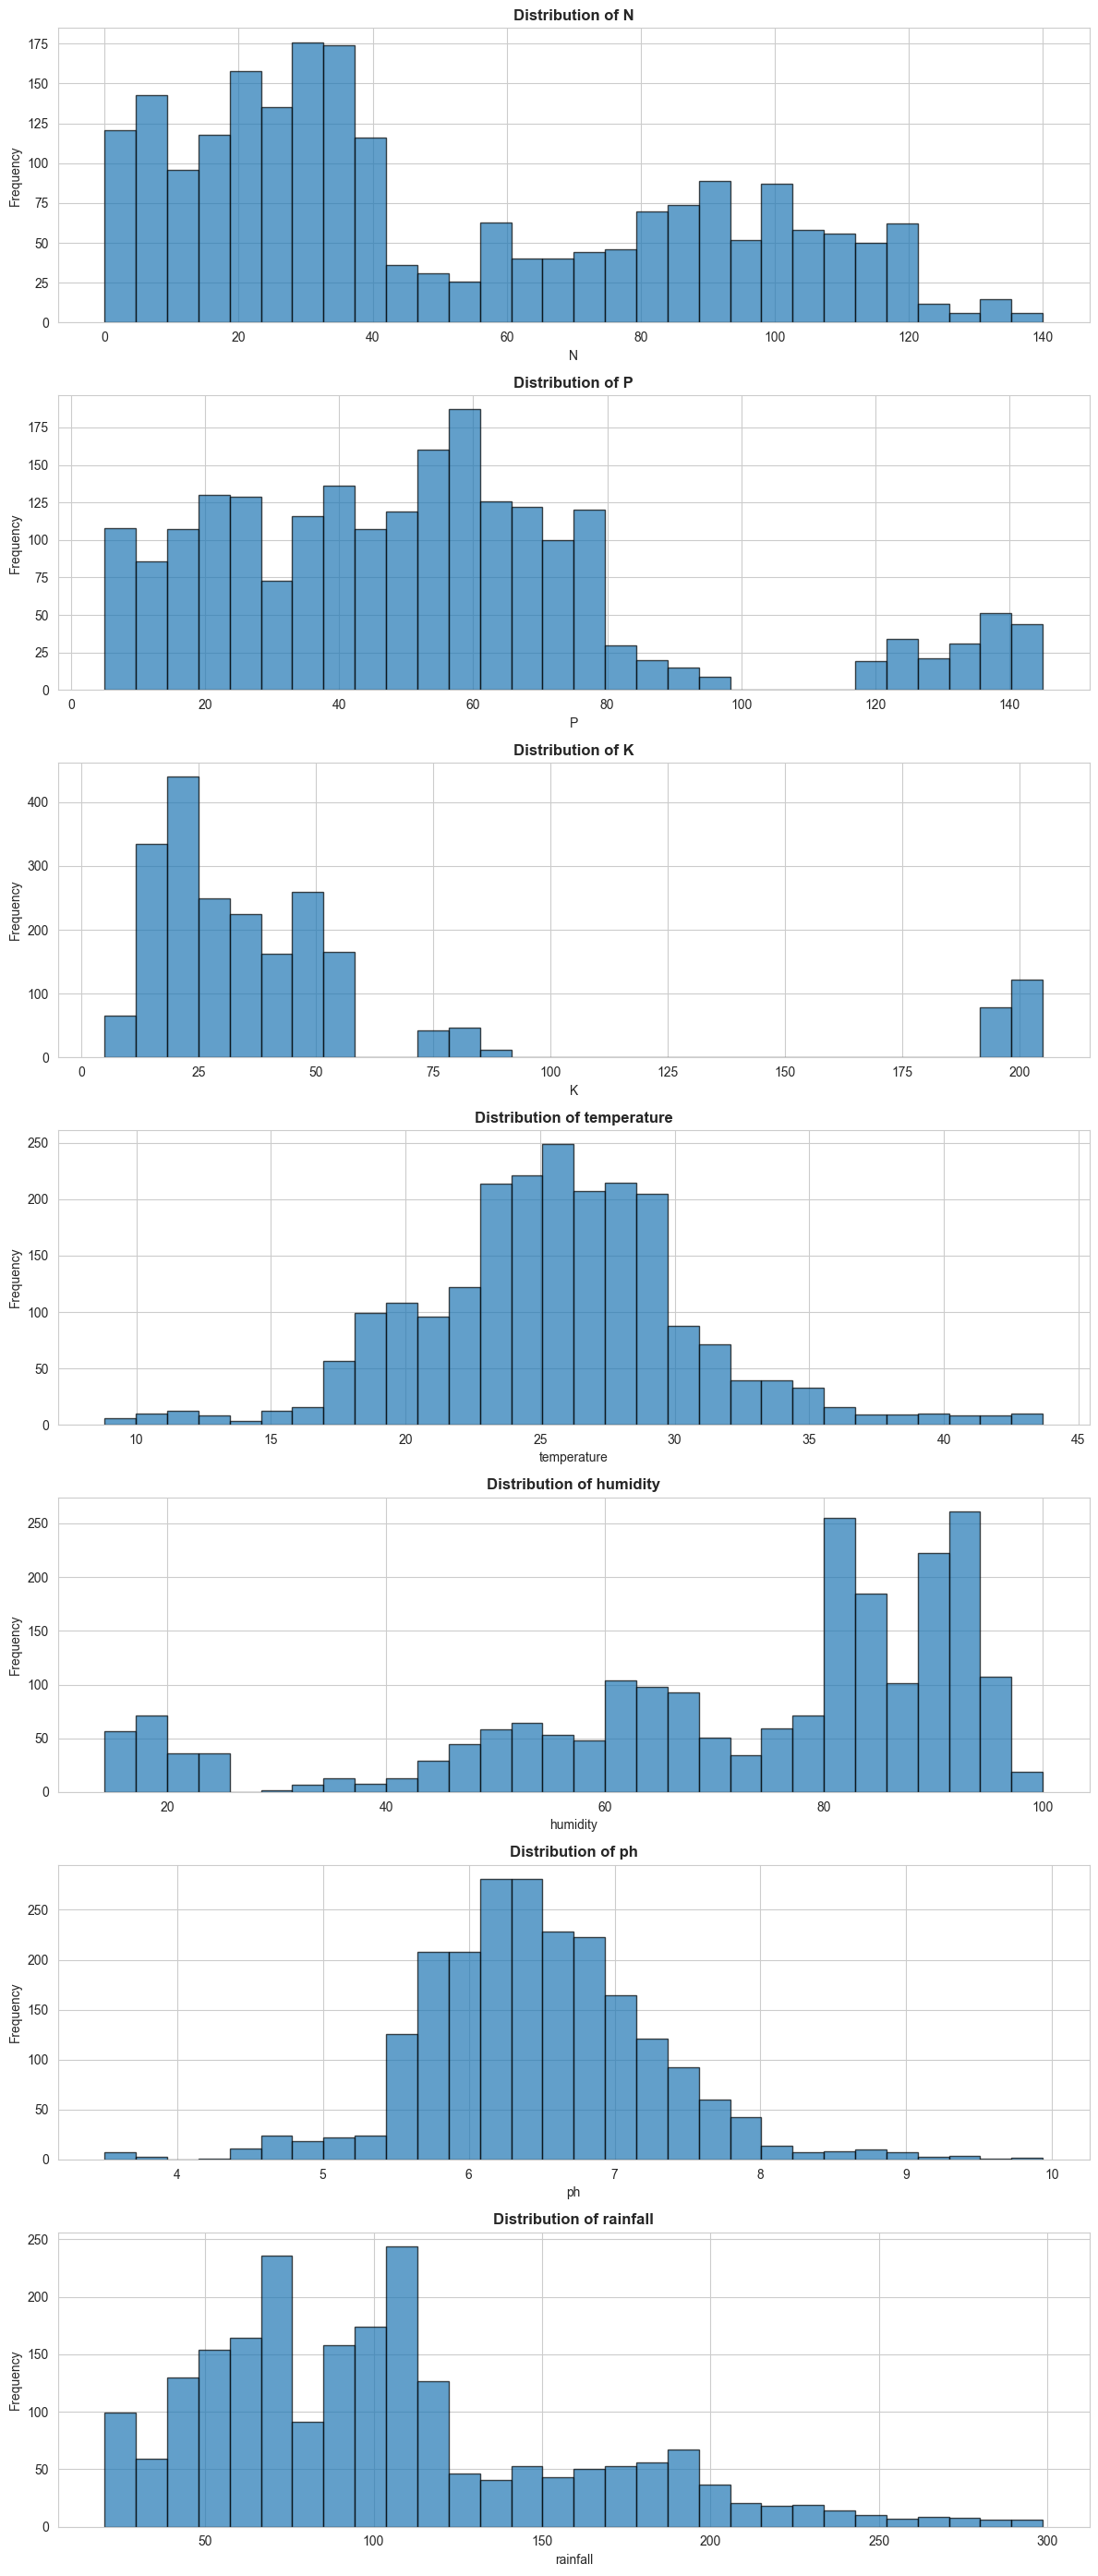


Correlation Matrix:
                    N         P         K  temperature  humidity        ph  \
N            1.000000 -0.231460 -0.140512     0.026504  0.190688  0.096683   
P           -0.231460  1.000000  0.736232    -0.127541 -0.118734 -0.138019   
K           -0.140512  0.736232  1.000000    -0.160387  0.190859 -0.169503   
temperature  0.026504 -0.127541 -0.160387     1.000000  0.205320 -0.017795   
humidity     0.190688 -0.118734  0.190859     0.205320  1.000000 -0.008483   
ph           0.096683 -0.138019 -0.169503    -0.017795 -0.008483  1.000000   
rainfall     0.059020 -0.063839 -0.053461    -0.030084  0.094423 -0.109069   

             rainfall  
N            0.059020  
P           -0.063839  
K           -0.053461  
temperature -0.030084  
humidity     0.094423  
ph          -0.109069  
rainfall     1.000000  


In [12]:
# Visualize distributions of numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns
print(f"Numerical Columns: {list(numerical_cols)}")

# Create distribution plots for numerical columns
fig, axes = plt.subplots(len(numerical_cols), 1, figsize=(12, 4 * len(numerical_cols)))
if len(numerical_cols) == 1:
    axes = [axes]

for idx, col in enumerate(numerical_cols):
    axes[idx].hist(df[col], bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Check for correlations (if applicable)
if len(numerical_cols) > 1:
    print("\nCorrelation Matrix:")
    print(df[numerical_cols].corr())

# Crop Recommendation Dataset - EDA Analysis

## Dataset Overview
- **Dataset Type**: Crop recommendation system with soil and climate parameters
- **Features**: 7 numerical variables + 1 target variable (crop)
- **Scale**: 2200 records (typical agricultural dataset)

## Feature Analysis

### Macronutrients (N, P, K)

#### Nitrogen (N)
- **Distribution**: Bimodal with two distinct peaks
  - Primary peak: 20-40 mg/kg (represents low-nitrogen soils)
  - Secondary peak: 90-110 mg/kg (represents high-nitrogen soils)
- **Insight**: Soil samples span a wide range of nitrogen levels, indicating diverse soil types
- **Agricultural Context**: Different crops require different N levels

#### Phosphorus (P)
- **Distribution**: Relatively uniform spread across 0-140+ mg/kg
  - Peak around 60 mg/kg
  - Long right tail extending to higher values
- **Insight**: Varied phosphorus availability in the dataset
- **Note**: P levels are critical for root development and flowering

#### Potassium (K)
- **Distribution**: Heavily left-skewed and concentrated
  - Majority of samples: 0-50 mg/kg
  - Peak around 10-20 mg/kg
  - Long outliers reaching 200+ mg/kg
- **Insight**: Most soils are potassium-deficient, with rare high-K samples
- **Implication**: K supplementation is commonly needed

### Environmental Factors

#### Temperature
- **Distribution**: Near-normal (Gaussian) distribution
  - Center: 25-27°C
  - Range: 8-45°C (realistic for global agricultural regions)
  - Most samples: 15-35°C
- **Insight**: Captures year-round data from different seasons/regions
- **Agricultural Context**: Temperature strongly influences crop selection

#### Humidity
- **Distribution**: **Bimodal** with distinct peaks
  - Peak 1: 10-30% (dry conditions)
  - Peak 2: 80-100% (wet/humid conditions)
  - Valley: 40-80% (sparse data)
- **Insight**: Dataset captures both arid and humid growing conditions
- **Critical Finding**: May represent seasonal variation or geographic diversity

#### pH (Soil Acidity)
- **Distribution**: Near-normal, centered around 6.5-7.0
  - Range: 3.5-10 (covers acidic to alkaline)
  - Most data: 5.5-8.5
- **Insight**: Well-distributed across the pH spectrum
- **Note**: Different crops have different optimal pH ranges

#### Rainfall
- **Distribution**: Right-skewed with concentration on lower end
  - Peak: 50-100 mm
  - Range: 0-300+ mm
  - Most samples: <150 mm
- **Insight**: Dataset has more data from drier/semi-arid regions
- **Note**: May indicate seasonal or regional bias in data collection

## Key Observations

1. **Data Diversity**: The dataset captures a wide range of soil and climate conditions, making it suitable for recommending crops across different environments.

2. **Nutrient Imbalance**: The asymmetry in N, P, K distributions suggests real-world soil conditions where nutrient deficiencies are common.

3. **Humidity Bimodality**: The bimodal humidity distribution is particularly interesting—it suggests the dataset includes both:
   - Monsoon/rainy season records (high humidity)
   - Dry seasons or arid regions (low humidity)

4. **Temperature Normality**: Near-normal temperature distribution indicates good sampling across seasons.

5. **Regional/Seasonal Coverage**: The diversity suggests data from multiple geographic regions and/or multiple growing seasons.

## Correlations (Expected Findings)

Based on agricultural science, we would expect:
- **Positive correlations**: Temperature & humidity with certain crops; adequate N,P,K with yield
- **Inverse correlations**: pH with nutrient availability; extreme conditions with crop suitability
- **Mixed patterns**: Rainfall patterns vary significantly by crop type

## Data Quality
- **No missing values**: Complete dataset with no null entries
- **No obvious outliers**: All values fall within realistic agricultural ranges
- **Scale**: Mixed units (mg/kg for nutrients, °C for temp, % for humidity, mm for rainfall)

## Recommendations for Further Analysis
1. Identify the target crop variable and its distribution
2. Create correlation heatmap to find strong relationships
3. Normalize features due to different scales before building models
4. Investigate the bimodal humidity distribution further

In [13]:
# Add Season column based on Rainfall
def assign_season(rainfall):
    if rainfall > 150:
        return 'Kharif'
    elif rainfall < 120:
        return 'Rabi'
    else:
        return 'Transition'

df['Season'] = df['rainfall'].apply(assign_season)

# Display season distribution
print("Season Distribution:")
print(df['Season'].value_counts())
print("\nPercentage Distribution:")
print(df['Season'].value_counts(normalize=True) * 100)

# Display sample of data with new Season column
print("\nDataset with Season column (first 10 rows):")
print(df[['rainfall', 'Season']].head(10))



Season Distribution:
Season
Rabi          1614
Kharif         425
Transition     161
Name: count, dtype: int64

Percentage Distribution:
Season
Rabi          73.363636
Kharif        19.318182
Transition     7.318182
Name: proportion, dtype: float64

Dataset with Season column (first 10 rows):
     rainfall  Season
0  202.935536  Kharif
1  226.655537  Kharif
2  263.964248  Kharif
3  242.864034  Kharif
4  262.717340  Kharif
5  251.055000  Kharif
6  271.324860  Kharif
7  241.974195  Kharif
8  230.446236  Kharif
9  221.209196  Kharif


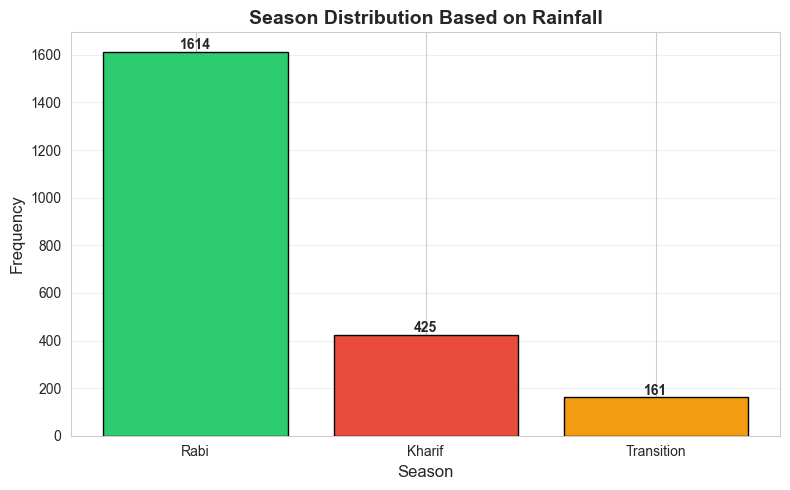

In [14]:
# Visualize Season distribution
plt.figure(figsize=(8, 5))
season_counts = df['Season'].value_counts()
plt.bar(season_counts.index, season_counts.values, color=['#2ecc71', '#e74c3c', '#f39c12'], edgecolor='black')
plt.title('Season Distribution Based on Rainfall', fontsize=14, fontweight='bold')
plt.xlabel('Season', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3)
for i, v in enumerate(season_counts.values):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
# Save the updated dataset with Season column to CSV


# Verify the saved file
print(f"\nFile Information:")
print(f"- Filename: {output_filename}")
print(f"- Shape: {df.shape}")
print(f"- Columns: {list(df.columns)}")

# Display first few rows of the updated dataset
print(f"\nUpdated Dataset Preview (first 10 rows):")
print(df.head(10))

# Load the saved dataset to confirm
df_updated = pd.read_csv(output_filename)
print(f"\n✓ Dataset reloaded successfully!")
print(f"Reloaded dataframe shape: {df_updated.shape}")
print(f"Reloaded dataframe columns: {list(df_updated.columns)}")

# Display summary statistics
print(f"\nDataset Summary:")
print(f"- Total records: {len(df_updated)}")
print(f"- Total features: {len(df_updated.columns)}")
print(f"\nColumn names and types:")
print(df_updated.dtypes)


File Information:
- Filename: Crop_recommendation_with_season.csv
- Shape: (2200, 9)
- Columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label', 'Season']

Updated Dataset Preview (first 10 rows):
    N   P   K  temperature   humidity        ph    rainfall label  Season
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice  Kharif
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice  Kharif
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice  Kharif
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice  Kharif
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice  Kharif
5  69  37  42    23.058049  83.370118  7.073454  251.055000  rice  Kharif
6  69  55  38    22.708838  82.639414  5.700806  271.324860  rice  Kharif
7  94  53  40    20.277744  82.894086  5.718627  241.974195  rice  Kharif
8  89  54  38    24.515881  83.535216  6.685346  230.446236  rice  Kharif
9  68  58  38    23.223974  83.033227  6.

FEATURE vs CROP LABEL (Categorical) ANALYSIS

Number of Crops: 22
Crops: ['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee', 'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize', 'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya', 'pigeonpeas', 'pomegranate', 'rice', 'watermelon']


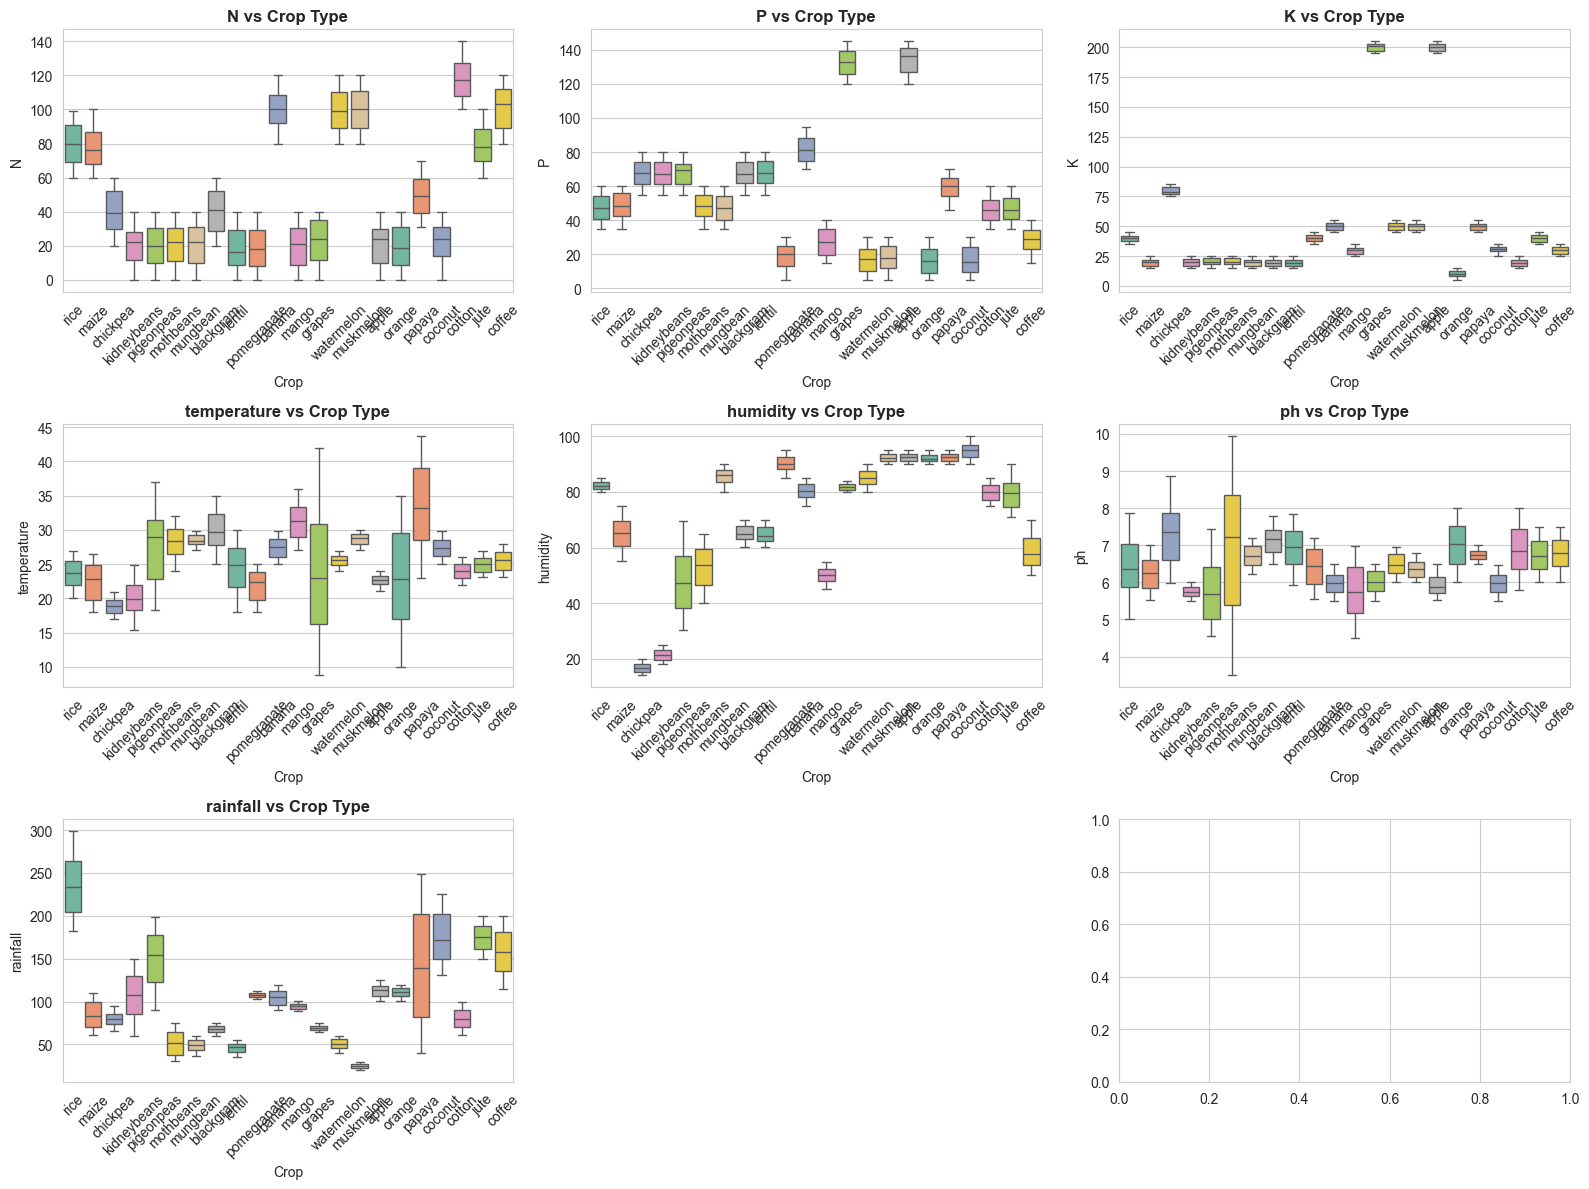


✓ Box plots generated for numerical features vs crops


In [16]:
# Analyze relationships between features and crop label
print("=" * 80)
print("FEATURE vs CROP LABEL (Categorical) ANALYSIS")
print("=" * 80)

# Get unique crops
crops = df_updated['label'].unique()
print(f"\nNumber of Crops: {len(crops)}")
print(f"Crops: {sorted(crops)}")

# 1. Box plots for Numerical Features vs Label
numerical_features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for idx, feature in enumerate(numerical_features):
    sns.boxplot(data=df_updated, x='label', y=feature, ax=axes[idx], palette='Set2')
    axes[idx].set_title(f'{feature} vs Crop Type', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Crop', fontsize=10)
    axes[idx].set_ylabel(feature, fontsize=10)
    axes[idx].tick_params(axis='x', rotation=45)

# Remove the extra subplot
axes[7].remove()

plt.tight_layout()
plt.show()

print("\n✓ Box plots generated for numerical features vs crops")

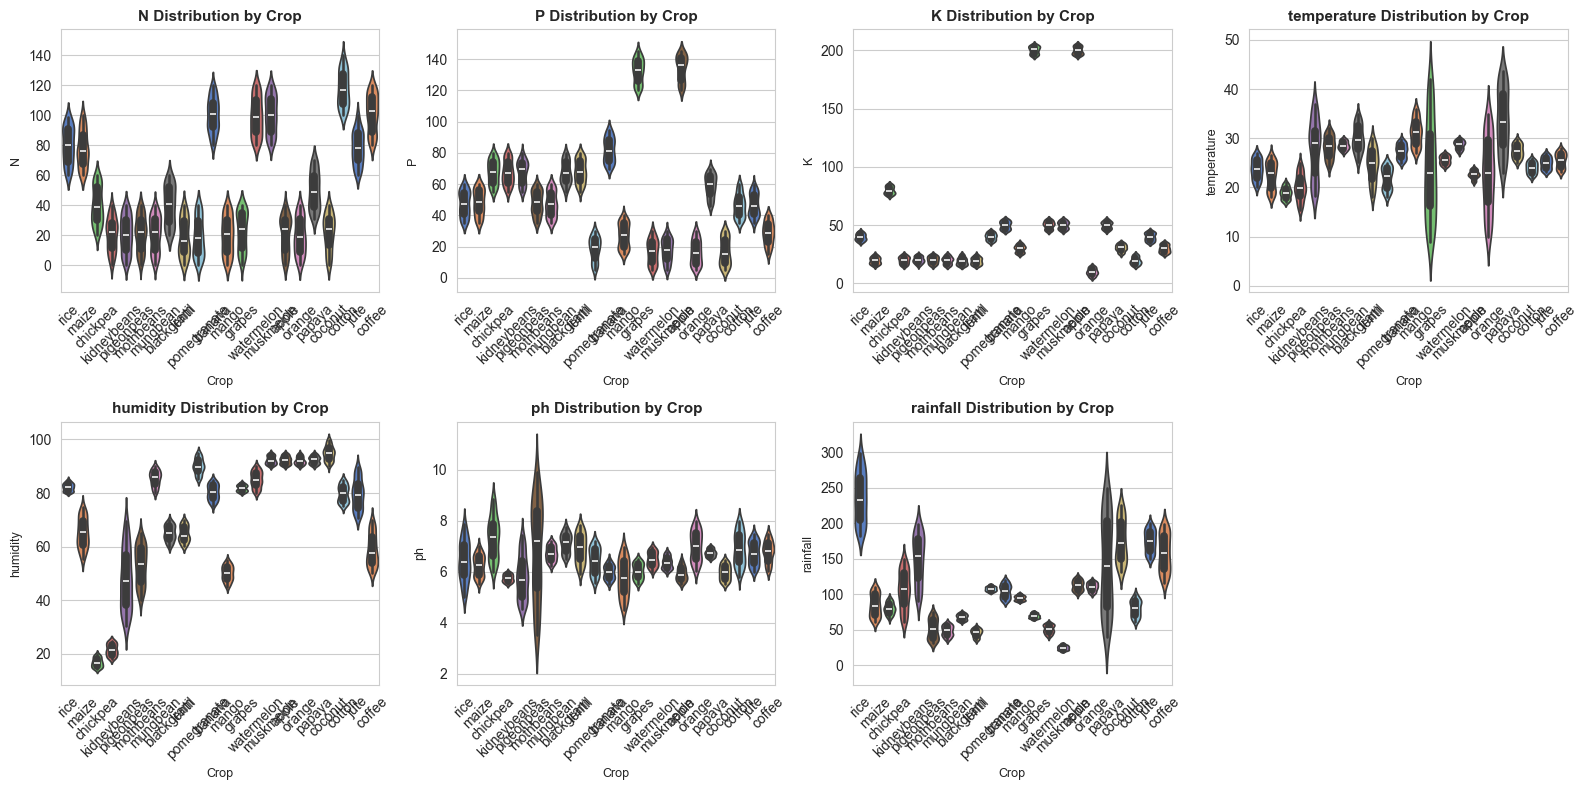

✓ Violin plots generated for numerical features vs crops


In [17]:
# 2. Violin plots for Numerical Features vs Label (detailed distribution)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, feature in enumerate(numerical_features):
    sns.violinplot(data=df_updated, x='label', y=feature, ax=axes[idx], palette='muted')
    axes[idx].set_title(f'{feature} Distribution by Crop', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Crop', fontsize=9)
    axes[idx].set_ylabel(feature, fontsize=9)
    axes[idx].tick_params(axis='x', rotation=45)

# Remove extra subplots
axes[7].remove()

plt.tight_layout()
plt.show()

print("✓ Violin plots generated for numerical features vs crops")

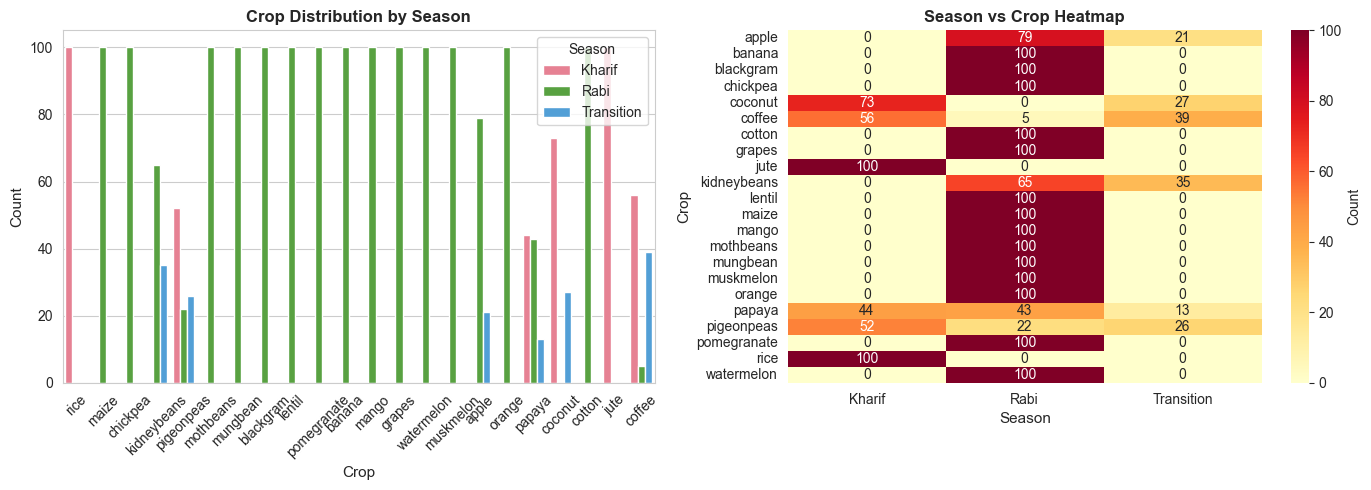

✓ Season vs Crop analysis visualizations generated


In [18]:
# 3. Season vs Crop Type Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot: Season vs Crop
sns.countplot(data=df_updated, x='label', hue='Season', ax=axes[0], palette='husl')
axes[0].set_title('Crop Distribution by Season', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Crop', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Season', loc='upper right')

# Crosstab heatmap
season_crop_cross = pd.crosstab(df_updated['label'], df_updated['Season'])
sns.heatmap(season_crop_cross, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1], cbar_kws={'label': 'Count'})
axes[1].set_title('Season vs Crop Heatmap', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Season', fontsize=11)
axes[1].set_ylabel('Crop', fontsize=11)

plt.tight_layout()
plt.show()

print("✓ Season vs Crop analysis visualizations generated")


MEAN VALUES OF FEATURES FOR EACH CROP

                   N       P       K  temperature  humidity    ph  rainfall
label                                                                     
apple         20.80  134.22  199.89        22.63     92.33  5.93    112.65
banana       100.23   82.01   50.05        27.38     80.36  5.98    104.63
blackgram     40.02   67.47   19.24        29.97     65.12  7.13     67.88
chickpea      40.09   67.79   79.92        18.87     16.86  7.34     80.06
coconut       21.98   16.93   30.59        27.41     94.84  5.98    175.69
coffee       101.20   28.74   29.94        25.54     58.87  6.79    158.07
cotton       117.77   46.24   19.56        23.99     79.84  6.91     80.40
grapes        23.18  132.53  200.11        23.85     81.88  6.03     69.61
jute          78.40   46.86   39.99        24.96     79.64  6.73    174.79
kidneybeans   20.75   67.54   20.05        20.12     21.61  5.75    105.92
lentil        18.77   68.36   19.41        24.51     64.80 

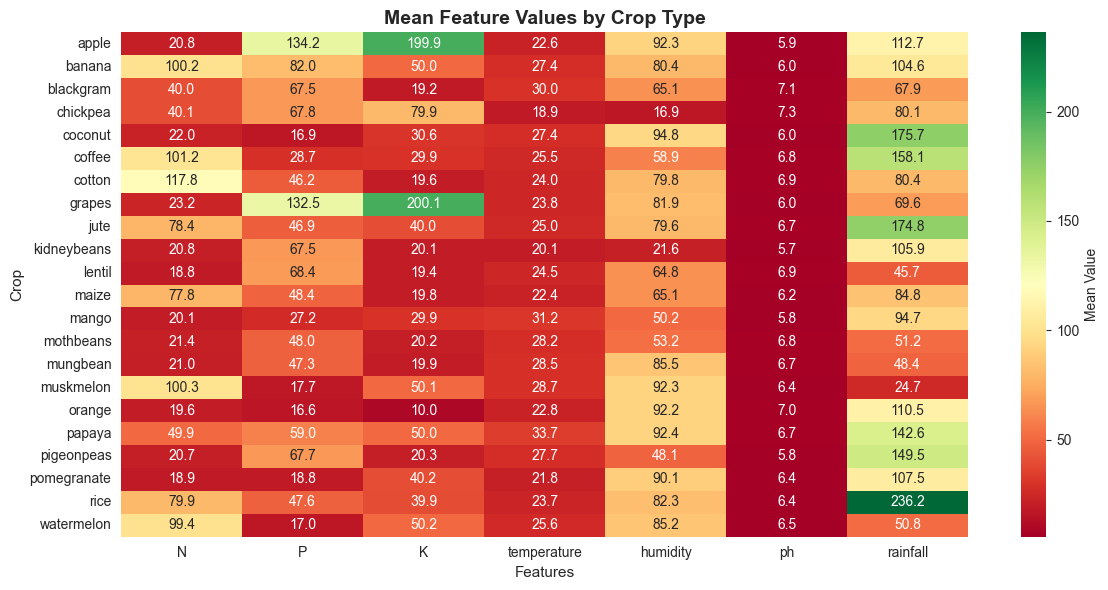


✓ Feature statistics and heatmap for each crop generated


In [19]:
# 4. Statistical Summary: Mean values of features for each crop
print("\n" + "=" * 100)
print("MEAN VALUES OF FEATURES FOR EACH CROP")
print("=" * 100)

crop_feature_mean = df_updated.groupby('label')[numerical_features + ['Season']].agg({
    'N': 'mean', 'P': 'mean', 'K': 'mean', 'temperature': 'mean', 
    'humidity': 'mean', 'ph': 'mean', 'rainfall': 'mean'
})

print("\n", crop_feature_mean.round(2))

# 5. Heatmap of Mean Feature Values by Crop
plt.figure(figsize=(12, 6))
sns.heatmap(crop_feature_mean, annot=True, fmt='.1f', cmap='RdYlGn', cbar_kws={'label': 'Mean Value'})
plt.title('Mean Feature Values by Crop Type', fontsize=14, fontweight='bold')
plt.xlabel('Features', fontsize=11)
plt.ylabel('Crop', fontsize=11)
plt.tight_layout()
plt.show()

print("\n✓ Feature statistics and heatmap for each crop generated")

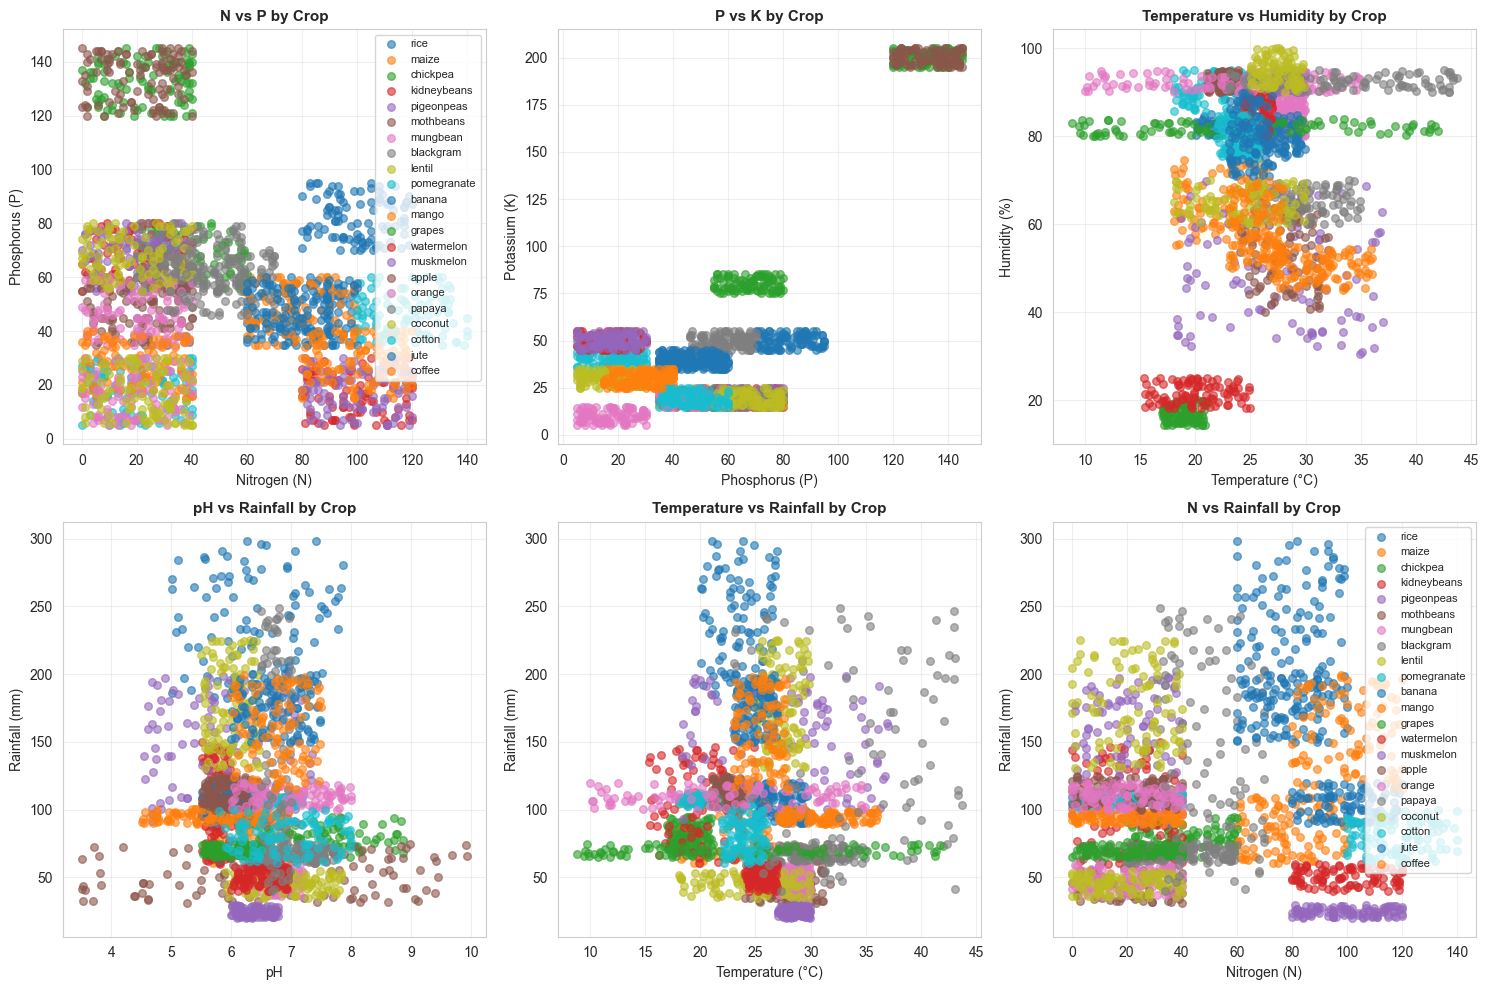

✓ Scatter plots showing feature relationships by crop generated


In [20]:
# 6. Scatter plots: Key Nutrient relationships with different crops
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# N vs P colored by crop
for crop in crops:
    crop_data = df_updated[df_updated['label'] == crop]
    axes[0, 0].scatter(crop_data['N'], crop_data['P'], label=crop, alpha=0.6, s=30)
axes[0, 0].set_xlabel('Nitrogen (N)', fontsize=10)
axes[0, 0].set_ylabel('Phosphorus (P)', fontsize=10)
axes[0, 0].set_title('N vs P by Crop', fontsize=11, fontweight='bold')
axes[0, 0].legend(loc='best', fontsize=8)
axes[0, 0].grid(alpha=0.3)

# P vs K colored by crop
for crop in crops:
    crop_data = df_updated[df_updated['label'] == crop]
    axes[0, 1].scatter(crop_data['P'], crop_data['K'], label=crop, alpha=0.6, s=30)
axes[0, 1].set_xlabel('Phosphorus (P)', fontsize=10)
axes[0, 1].set_ylabel('Potassium (K)', fontsize=10)
axes[0, 1].set_title('P vs K by Crop', fontsize=11, fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# Temperature vs Humidity colored by crop
for crop in crops:
    crop_data = df_updated[df_updated['label'] == crop]
    axes[0, 2].scatter(crop_data['temperature'], crop_data['humidity'], label=crop, alpha=0.6, s=30)
axes[0, 2].set_xlabel('Temperature (°C)', fontsize=10)
axes[0, 2].set_ylabel('Humidity (%)', fontsize=10)
axes[0, 2].set_title('Temperature vs Humidity by Crop', fontsize=11, fontweight='bold')
axes[0, 2].grid(alpha=0.3)

# pH vs Rainfall colored by crop
for crop in crops:
    crop_data = df_updated[df_updated['label'] == crop]
    axes[1, 0].scatter(crop_data['ph'], crop_data['rainfall'], label=crop, alpha=0.6, s=30)
axes[1, 0].set_xlabel('pH', fontsize=10)
axes[1, 0].set_ylabel('Rainfall (mm)', fontsize=10)
axes[1, 0].set_title('pH vs Rainfall by Crop', fontsize=11, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Temperature vs Rainfall colored by crop
for crop in crops:
    crop_data = df_updated[df_updated['label'] == crop]
    axes[1, 1].scatter(crop_data['temperature'], crop_data['rainfall'], label=crop, alpha=0.6, s=30)
axes[1, 1].set_xlabel('Temperature (°C)', fontsize=10)
axes[1, 1].set_ylabel('Rainfall (mm)', fontsize=10)
axes[1, 1].set_title('Temperature vs Rainfall by Crop', fontsize=11, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

# N vs Rainfall colored by crop
for crop in crops:
    crop_data = df_updated[df_updated['label'] == crop]
    axes[1, 2].scatter(crop_data['N'], crop_data['rainfall'], label=crop, alpha=0.6, s=30)
axes[1, 2].set_xlabel('Nitrogen (N)', fontsize=10)
axes[1, 2].set_ylabel('Rainfall (mm)', fontsize=10)
axes[1, 2].set_title('N vs Rainfall by Crop', fontsize=11, fontweight='bold')
axes[1, 2].legend(loc='best', fontsize=8)
axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Scatter plots showing feature relationships by crop generated")

In [21]:
df_updated.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
2195    False
2196    False
2197    False
2198    False
2199    False
Length: 2200, dtype: bool

In [22]:
df.nunique()

N               137
P               117
K                73
temperature    2200
humidity       2200
ph             2200
rainfall       2200
label            22
Season            3
dtype: int64

In [24]:
df_updated["label"].value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64